# 05 — WOE Scorecard
**TrustGraph Credit Risk Project**

Builds an interpretable WOE scorecard using vectorised quantile binning + logistic regression.
Points are assigned via PDO (points to double the odds) scaling — readable by loan officers.

In [1]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

ROOT       = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'notebooks' else Path(os.getcwd())
DATA_PROC  = ROOT / 'data' / 'processed'
CHARTS_DIR = DATA_PROC / 'eda_charts'
MODELS_DIR = ROOT / 'models'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

FEAT_FILE = DATA_PROC / 'features_train.csv'
if not FEAT_FILE.exists():
    raise FileNotFoundError(f"{FEAT_FILE} — run 03_features.ipynb first.")
print('Imports OK')

Imports OK


## 1. Vectorised WOE utilities

In [2]:
def compute_woe_bins(series, target, n_bins=10):
    eps = 1e-6
    total_ev  = float(target.sum())
    total_nev = float(len(target) - total_ev)
    records   = []

    miss_mask = series.isna()
    if miss_mask.any():
        ev   = float(target[miss_mask].sum())
        nev  = float(miss_mask.sum() - ev)
        d_ev = ev  / total_ev  + eps
        d_nv = nev / total_nev + eps
        woe  = np.log(d_ev / d_nv)
        records.append({'Bin':'MISSING','Low':np.nan,'High':np.nan,
                        'Count':int(miss_mask.sum()),'Events':int(ev),'NonEvents':int(nev),
                        'EventRate':ev/max(miss_mask.sum(),1),'WoE':woe,'IV':(d_ev-d_nv)*woe})

    clean = series[~miss_mask].values
    tgt_c = target[~miss_mask].values
    bps   = np.unique(np.percentile(clean, np.linspace(0, 100, n_bins + 1)))

    for i in range(len(bps) - 1):
        lo, hi = bps[i], bps[i+1]
        mask = (clean >= lo) & (clean <= hi) if i == len(bps)-2 else (clean >= lo) & (clean < hi)
        if mask.sum() == 0:
            continue
        ev   = float(tgt_c[mask].sum())
        nev  = float(mask.sum() - ev)
        d_ev = ev  / total_ev  + eps
        d_nv = nev / total_nev + eps
        woe  = np.log(d_ev / d_nv)
        records.append({'Bin':f'[{lo:.4g},{hi:.4g})','Low':lo,'High':hi,
                        'Count':int(mask.sum()),'Events':int(ev),'NonEvents':int(nev),
                        'EventRate':ev/max(mask.sum(),1),'WoE':woe,'IV':(d_ev-d_nv)*woe})
    return pd.DataFrame(records)


def fit_woe_pipeline(X, y, features, n_bins=10):
    pipeline = {}
    for feat in features:
        tbl   = compute_woe_bins(X[feat], y, n_bins=n_bins)
        clean = X[feat].dropna().values
        bps   = np.unique(np.percentile(clean, np.linspace(0,100,n_bins+1))) if len(clean) else np.array([])
        pipeline[feat] = {'table': tbl, 'breakpoints': bps, 'iv': tbl['IV'].sum()}
    return pipeline


def apply_woe_pipeline(X, pipeline):
    """Vectorised WOE transform using np.digitize — no per-row Python loops."""
    out = {}
    for feat, info in pipeline.items():
        tbl  = info['table']
        bps  = info['breakpoints']
        vals = X[feat].values.astype(float)
        result = np.zeros(len(vals))

        miss_rows = tbl[tbl['Bin'] == 'MISSING']
        miss_woe  = float(miss_rows['WoE'].iloc[0]) if len(miss_rows) else 0.0
        non_miss  = tbl[tbl['Bin'] != 'MISSING'].reset_index(drop=True)
        woe_arr   = non_miss['WoE'].values.astype(float)

        nan_mask = np.isnan(vals)
        result[nan_mask] = miss_woe

        if len(bps) >= 2 and len(woe_arr) > 0:
            num_vals = vals[~nan_mask]
            bin_idx  = np.digitize(num_vals, bps[1:], right=False)
            bin_idx  = np.clip(bin_idx, 0, len(woe_arr) - 1)
            result[~nan_mask] = woe_arr[bin_idx]

        out[f'{feat}_WOE'] = result
    return pd.DataFrame(out, index=X.index)

print('WOE utilities ready.')

WOE utilities ready.


## 2. Load data and split

In [3]:
df = pd.read_csv(FEAT_FILE)
print(f'Shape: {df.shape}  |  Default rate: {df["TARGET"].mean():.3%}')

SCORECARD_FEATURES = [
    'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN',
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM',
    'DAYS_EMPLOYED_RATIO', 'AMT_CREDIT', 'AMT_INCOME_TOTAL',
    'DAYS_BIRTH', 'FLAG_MISSING_EXT',
]
SCORECARD_FEATURES = [f for f in SCORECARD_FEATURES if f in df.columns]
print(f'Features ({len(SCORECARD_FEATURES)}): {SCORECARD_FEATURES}')

y = df['TARGET']
X = df[SCORECARD_FEATURES].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}  Val: {X_val.shape}')

Shape: (307511, 130)  |  Default rate: 8.073%
Features (10): ['EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM', 'DAYS_EMPLOYED_RATIO', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'FLAG_MISSING_EXT']


Train: (246008, 10)  Val: (61503, 10)


## 3. Fit WOE pipeline and transform

In [4]:
woe_pipeline = fit_woe_pipeline(X_train, y_train, SCORECARD_FEATURES, n_bins=10)

X_train_woe = apply_woe_pipeline(X_train, woe_pipeline)
X_val_woe   = apply_woe_pipeline(X_val,   woe_pipeline)

iv_df = pd.DataFrame([
    {'Feature': f, 'IV': round(info['iv'], 4),
     'Strength': 'Strong' if info['iv'] > 0.3 else 'Medium' if info['iv'] > 0.1 else 'Weak'}
    for f, info in woe_pipeline.items()
]).sort_values('IV', ascending=False)
print(iv_df.to_string(index=False))

             Feature     IV Strength
     EXT_SOURCE_MEAN 0.6092   Strong
      EXT_SOURCE_MIN 0.4656   Strong
         CREDIT_TERM 0.0915     Weak
 DAYS_EMPLOYED_RATIO 0.0885     Weak
          DAYS_BIRTH 0.0868     Weak
          AMT_CREDIT 0.0469     Weak
    AMT_INCOME_TOTAL 0.0113     Weak
 CREDIT_INCOME_RATIO 0.0111     Weak
ANNUITY_INCOME_RATIO 0.0063     Weak
    FLAG_MISSING_EXT 0.0000     Weak


## 4. Train Logistic Regression on WOE features

In [5]:
lr = LogisticRegression(solver='lbfgs', max_iter=1000,
                         class_weight='balanced', random_state=RANDOM_STATE)
lr.fit(X_train_woe, y_train)
print('Logistic Regression trained.')

Logistic Regression trained.


## 5. Evaluate: AUC-ROC and KS

In [6]:
prob_val = lr.predict_proba(X_val_woe)[:, 1]
auc_sc   = roc_auc_score(y_val, prob_val)
ks_sc, _ = ks_2samp(prob_val[y_val == 1], prob_val[y_val == 0])

lgbm_auc, lgbm_ks = 0.7707, 0.4049

cmp = pd.DataFrame({
    'Model':         ['LightGBM (04)', 'WOE Scorecard (05)'],
    'AUC_ROC':       [lgbm_auc, round(auc_sc, 4)],
    'KS_Statistic':  [lgbm_ks,  round(ks_sc,  4)],
    'Interpretable': ['No', 'Yes — points table'],
})
print(cmp.to_string(index=False))

             Model  AUC_ROC  KS_Statistic      Interpretable
     LightGBM (04)   0.7707        0.4049                 No
WOE Scorecard (05)   0.7286        0.3434 Yes — points table


## 6. Scorecard points table (PDO scaling)

In [7]:
PDO, ODDS, BASE = 20, 1, 600
factor   = PDO / np.log(2)
coef_map = dict(zip(X_train_woe.columns, lr.coef_[0]))
intercept = float(lr.intercept_[0])
n_feats   = len(SCORECARD_FEATURES)

sc_rows = []
for feat in SCORECARD_FEATURES:
    coef = coef_map.get(f'{feat}_WOE', 0.0)
    tbl  = woe_pipeline[feat]['table'].copy()
    tbl['Variable']    = feat
    tbl['Coefficient'] = coef
    tbl['Points']      = (-(tbl['WoE'] * coef + intercept / n_feats) * factor).round(1)
    sc_rows.append(tbl[['Variable','Bin','Count','EventRate','WoE','IV','Points']])

sc_table = pd.concat(sc_rows, ignore_index=True)
sc_table[['EventRate','WoE','IV']] = sc_table[['EventRate','WoE','IV']].round(4)

sc_path = DATA_PROC / 'scorecard_table.csv'
sc_table.to_csv(sc_path, index=False)
print(f'Saved: {sc_path}  ({len(sc_table)} rows)')
sc_table.head(20)

Saved: C:\Users\krish\Downloads\TrustGraph\data\processed\scorecard_table.csv  (91 rows)


,Variable,Bin,Count,EventRate,WoE,IV,Points
0,EXT_SOURCE_MEAN,"[1.147e-05,0.3038)",24601,0.2293,1.2200,0.2442,-30.7
1,EXT_SOURCE_MEAN,"[0.3038,0.3843)",24601,0.1443,0.6525,0.0559,-16.4
2,EXT_SOURCE_MEAN,"[0.3843,0.4392)",24601,0.1049,0.2883,0.0094,-7.3
3,EXT_SOURCE_MEAN,"[0.4392,0.4838)",24600,0.0809,0.0028,0.0000,-0.1
4,EXT_SOURCE_MEAN,"[0.4838,0.5243)",24601,0.0660,-0.2171,0.0043,5.5
5,EXT_SOURCE_MEAN,"[0.5243,0.5634)",24601,0.0550,-0.4114,0.0143,10.4
6,EXT_SOURCE_MEAN,"[0.5634,0.6023)",24600,0.0407,-0.7277,0.0393,18.3
7,EXT_SOURCE_MEAN,"[0.6023,0.6439)",24601,0.0367,-0.8361,0.0496,21.0
8,EXT_SOURCE_MEAN,"[0.6439,0.6926)",24601,0.0295,-1.0620,0.0734,26.7
9,EXT_SOURCE_MEAN,"[0.6926,0.8789)",24601,0.0201,-1.4552,0.1189,36.6


## 7. WOE charts — top 5 features

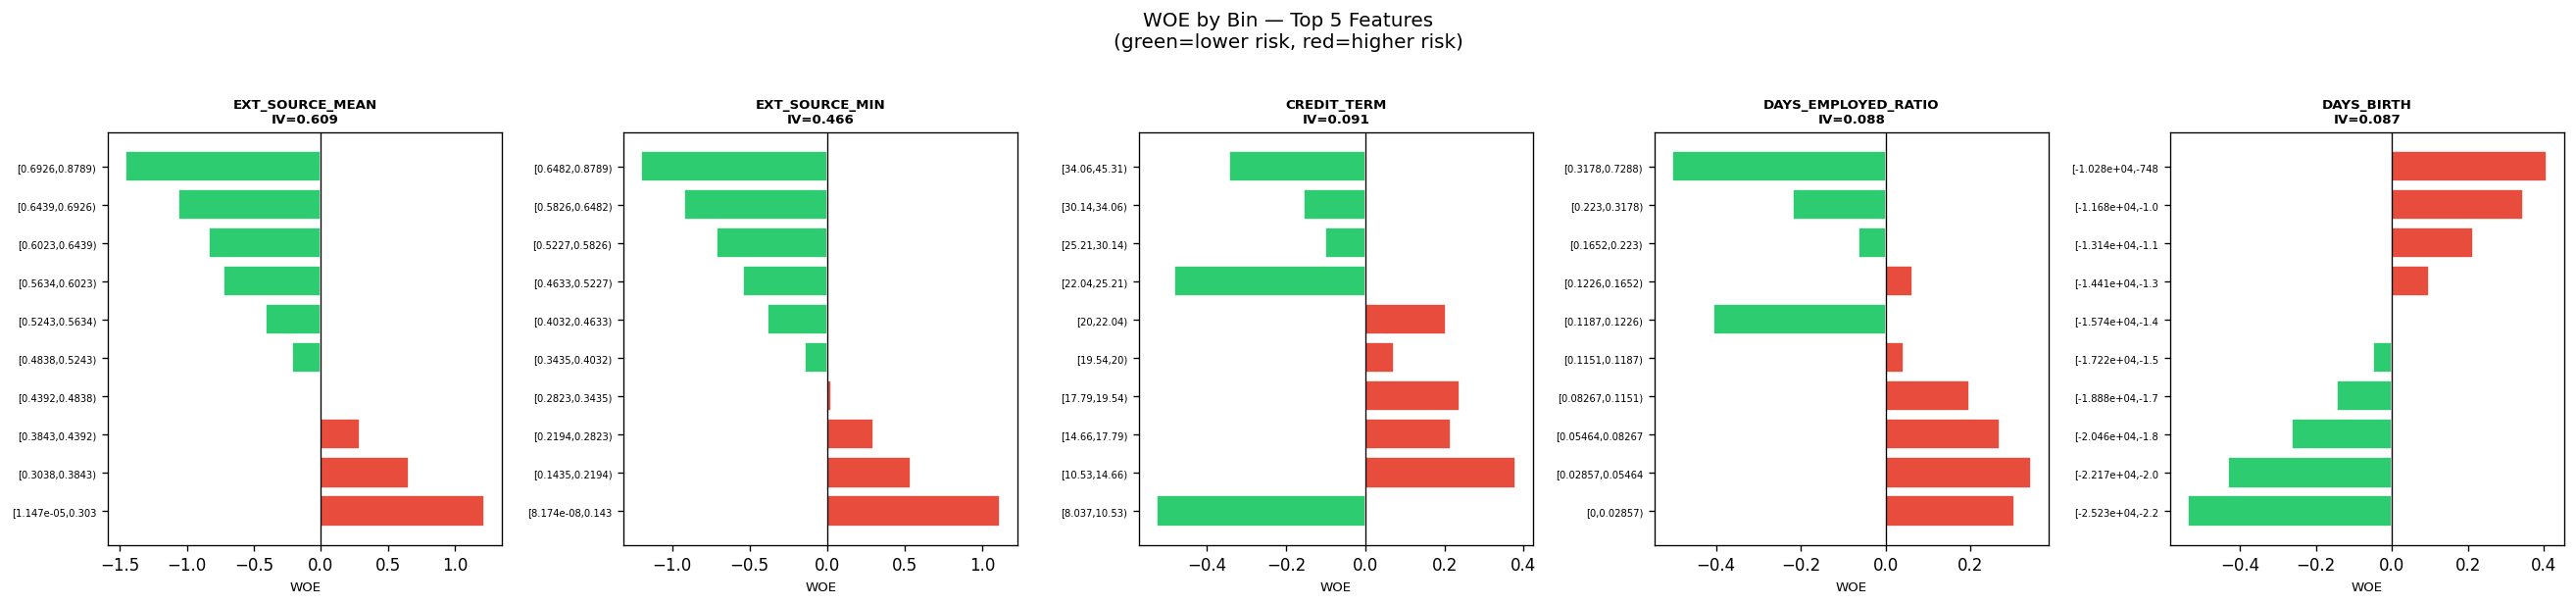

Saved: C:\Users\krish\Downloads\TrustGraph\data\processed\eda_charts\woe_charts.png


In [8]:
top5_feats = iv_df.head(5)['Feature'].tolist()
fig, axes  = plt.subplots(1, 5, figsize=(22, 5))

for ax, feat in zip(axes, top5_feats):
    tbl = sc_table[sc_table['Variable'] == feat].copy()
    if tbl.empty:
        ax.set_visible(False)
        continue
    bins   = [str(b)[:16] for b in tbl['Bin']]
    woes   = tbl['WoE'].astype(float).values
    colors = ['#2ecc71' if w < 0 else '#e74c3c' for w in woes]
    ax.barh(bins, woes, color=colors, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'{feat}\nIV={tbl["IV"].sum():.3f}', fontsize=8, fontweight='bold')
    ax.set_xlabel('WOE', fontsize=8)
    ax.tick_params(axis='y', labelsize=6)

plt.suptitle('WOE by Bin — Top 5 Features\n(green=lower risk, red=higher risk)', fontsize=12, y=1.02)
plt.tight_layout()
woe_path = CHARTS_DIR / 'woe_charts.png'
plt.savefig(woe_path, bbox_inches='tight')
plt.show()
print(f'Saved: {woe_path}')

## 8. Save model

In [9]:
sc_model_path = MODELS_DIR / 'scorecard_final.pkl'
with open(sc_model_path, 'wb') as f:
    pickle.dump({
        'lr_model': lr,
        'woe_pipeline': woe_pipeline,
        'features': SCORECARD_FEATURES,
        'woe_feature_names': list(X_train_woe.columns),
    }, f)
print(f'Saved: {sc_model_path}')

Saved: C:\Users\krish\Downloads\TrustGraph\models\scorecard_final.pkl


## 9. Final comparison

In [10]:
print('=' * 56)
print('  WOE SCORECARD vs LIGHTGBM')
print('=' * 56)
print(f'  LightGBM   AUC: {lgbm_auc:.4f}   KS: {lgbm_ks:.4f}')
print(f'  Scorecard  AUC: {auc_sc:.4f}   KS: {ks_sc:.4f}')
print(f'  AUC gap:  {lgbm_auc - auc_sc:+.4f}   KS gap: {lgbm_ks - ks_sc:+.4f}')
print('=' * 56)
print()
print('  Scorecard trades predictive power for full auditability.')
print('  Every point per bin is readable — required for RBI compliance.')

  WOE SCORECARD vs LIGHTGBM
  LightGBM   AUC: 0.7707   KS: 0.4049
  Scorecard  AUC: 0.7286   KS: 0.3434
  AUC gap:  +0.0421   KS gap: +0.0615

  Scorecard trades predictive power for full auditability.
  Every point per bin is readable — required for RBI compliance.
